In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [116]:

def f(a, b):
    if b <= 0.5:
        return np.maximum(0, 1 - a * (1 - 2 * b) * (1 - b))
    else:
        return np.minimum(1, -a * (1 - 2 * b) * b)

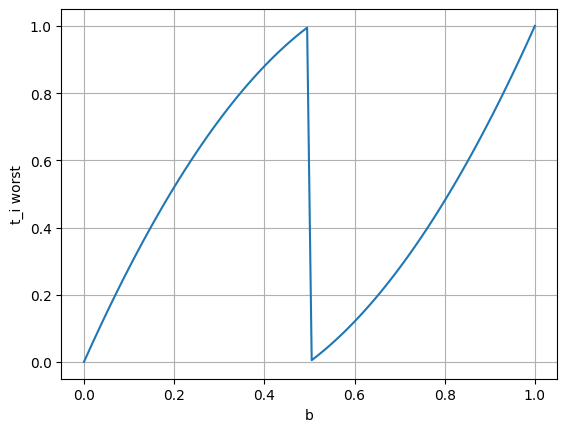

In [147]:
a = 1
bs = np.linspace(0, 1, 100)

xs = np.zeros((len(bs)))
for i, b in enumerate(bs):
    xs[i] = f(a, b)

plt.plot(bs, xs)
plt.xlabel("b")
plt.ylabel("t_i worst")
plt.grid()

In [185]:
def _allocations_to_transfers(allocations, types):
    return (
        types * allocations
        + np.minimum(-allocations, 0)
        - np.cumsum(allocations) / len(types)
    )

def _allocations_to_externalities(allocations,types, tau, prob_state0):

    def externality_for_type(type, x):
        ps1 = 1 - prob_state0 - prob_state0 * x + (1 - 2 * prob_state0) * np.minimum(0, -x)
        externality = ps1
        externality *= 1 - 2 * prob_state0
        externality *= tau

        return externality + tau * prob_state0

    return externality_for_type(types, allocations)


def objective(allocations, types, tau, prob_state0):


    # integral = np.cumsum(q) / len(x)
    # return x * q + np.minimum(-q, 0) - integral - a * b - a * (1-2*b) * (1 - b - b * q + (1 - 2 * b) * np.minimum(-q, 0))
    
    return _allocations_to_transfers(allocations, types) - _allocations_to_externalities(allocations,types, tau, prob_state0)
    #return -_allocations_to_externalities(allocations,types, tau, prob_state0)



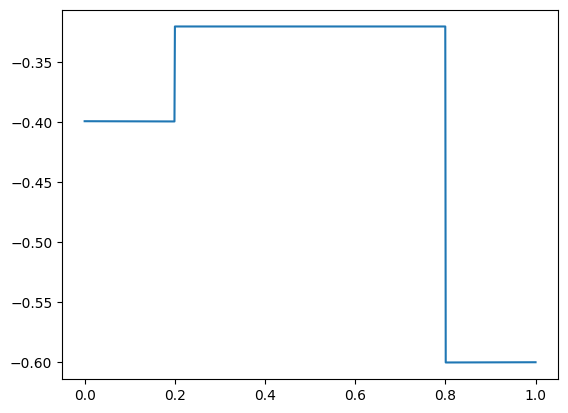

In [194]:

b = 0.6

xs = np.linspace(0, 1, 1000)

qs = np.zeros(len(xs))
# qs[:250] = -1
# qs[750:] = 1

# qs = np.zeros(len(xs))
qs[:200] = -1
qs[800:] = 1

plt.plot(xs, objective(qs, xs, a, b))

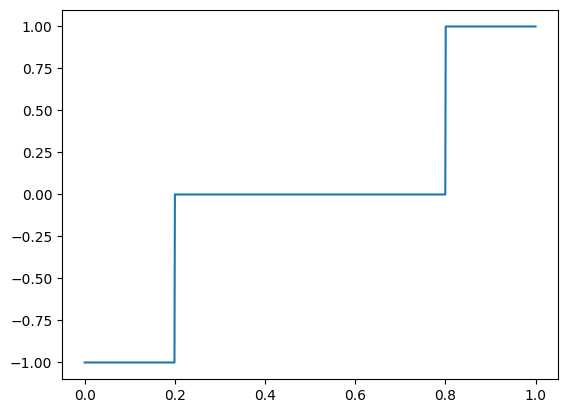

In [195]:
plt.plot(xs, qs)

In [180]:
min_type, min_obj, qq

(0.0, -0.68, 0.0)

In [171]:
a = 1
b = 0.8

for b in [0.501, 0.6, 0.7, 0.8, 0.9, 1]:
    x1 = -a * (1 - 2 * b) * b
    print(x1)

# x1 = -a * (1 - 2 * b) * b
# x2 = 1 - a * (1 - 2 * b) * (1 - b)
# x1, x2

0.001002000000000001
0.11999999999999997
0.2799999999999999
0.4800000000000001
0.7200000000000001
1


In [81]:
import numpy as np

prob_x0 = 0.6
prob_x1 = 1 - prob_x0

prob_a0_x0 = 0
prob_a1_x0 = 1 - prob_a0_x0

prob_a1_x1 = 0
prob_a0_x1 = 1 - prob_a1_x1

prob_x0_a0 = (prob_x0 * prob_a0_x0) / (prob_x0 * prob_a0_x0 + prob_x1 * prob_a0_x1)
prob_x0_a1 = (prob_x0 * prob_a1_x0) / (prob_x0 * prob_a1_x0 + prob_x1 * prob_a1_x1)
prob_x0_a0, prob_x0_a1

(0.0, 1.0)

In [82]:
prob_x0 * prob_a0_x0 + prob_x1 * prob_a0_x1, prob_x0 * prob_a1_x0 + prob_x1 * prob_a1_x1

(0.4, 0.6)

In [95]:
import numpy as np

prob_x0 = 0.9
prob_x1 = 1 - prob_x0

prob_a0_x0 = 0.5
prob_a1_x0 = 1 - prob_a0_x0

prob_a1_x1 = 0.5
prob_a0_x1 = 1 - prob_a1_x1

prob_x0_a0 = (prob_x0 * prob_a0_x0) / (prob_x0 * prob_a0_x0 + prob_x1 * prob_a0_x1)
prob_x0_a1 = (prob_x0 * prob_a1_x0) / (prob_x0 * prob_a1_x0 + prob_x1 * prob_a1_x1)
prob_x0_a0, prob_x0_a1

(0.9, 0.9)

In [93]:
1 - (prob_x0 * prob_a0_x0 + prob_x1 * prob_a0_x1)

0.9999